In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import metrics

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
from sklearn import svm

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
from sklearn.model_selection import train_test_split

In [46]:
from sklearn import datasets

In [7]:
iris = pd.read_csv('iris_dataset.csv')

In [8]:
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [9]:
print(iris)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm    Species
0      1            5.1           3.5            1.4           0.2     setosa
1      2            4.9           3.0            1.4           0.2     setosa
2      3            4.7           3.2            1.3           0.2     setosa
3      4            4.6           3.1            1.5           0.2     setosa
4      5            5.0           3.6            1.4           0.2     setosa
..   ...            ...           ...            ...           ...        ...
145  146            6.7           3.0            5.2           2.3  virginica
146  147            6.3           2.5            5.0           1.9  virginica
147  148            6.5           3.0            5.2           2.0  virginica
148  149            6.2           3.4            5.4           2.3  virginica
149  150            5.9           3.0            5.1           1.8  virginica

[150 rows x 6 columns]


In [10]:
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [47]:
print(datasets.load_iris()['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [11]:
train, test = train_test_split(iris, test_size=0.25)

In [12]:
train

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
45,46,4.8,3.0,1.4,0.3,setosa
137,138,6.4,3.1,5.5,1.8,virginica
128,129,6.4,2.8,5.6,2.1,virginica
9,10,4.9,3.1,1.5,0.1,setosa
94,95,5.6,2.7,4.2,1.3,versicolor
...,...,...,...,...,...,...
73,74,6.1,2.8,4.7,1.2,versicolor
102,103,7.1,3.0,5.9,2.1,virginica
139,140,6.9,3.1,5.4,2.1,virginica
60,61,5.0,2.0,3.5,1.0,versicolor


In [34]:
train.corr

<bound method DataFrame.corr of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm     Species
45    46            4.8           3.0            1.4           0.3      setosa
137  138            6.4           3.1            5.5           1.8   virginica
128  129            6.4           2.8            5.6           2.1   virginica
9     10            4.9           3.1            1.5           0.1      setosa
94    95            5.6           2.7            4.2           1.3  versicolor
..   ...            ...           ...            ...           ...         ...
73    74            6.1           2.8            4.7           1.2  versicolor
102  103            7.1           3.0            5.9           2.1   virginica
139  140            6.9           3.1            5.4           2.1   virginica
60    61            5.0           2.0            3.5           1.0  versicolor
86    87            6.7           3.1            4.7           1.5  versicolor

[112 rows x 6 colum

In [13]:
test

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
12,13,4.8,3.0,1.4,0.1,setosa
127,128,6.1,3.0,4.9,1.8,virginica
135,136,7.7,3.0,6.1,2.3,virginica
115,116,6.4,3.2,5.3,2.3,virginica
148,149,6.2,3.4,5.4,2.3,virginica
31,32,5.4,3.4,1.5,0.4,setosa
122,123,7.7,2.8,6.7,2.0,virginica
16,17,5.4,3.9,1.3,0.4,setosa
67,68,5.8,2.7,4.1,1.0,versicolor
91,92,6.1,3.0,4.6,1.4,versicolor


In [14]:
train_x = train[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]

In [15]:
train_y = train.Species

In [16]:
train_x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
45,4.8,3.0,1.4,0.3
137,6.4,3.1,5.5,1.8
128,6.4,2.8,5.6,2.1
9,4.9,3.1,1.5,0.1
94,5.6,2.7,4.2,1.3
...,...,...,...,...
73,6.1,2.8,4.7,1.2
102,7.1,3.0,5.9,2.1
139,6.9,3.1,5.4,2.1
60,5.0,2.0,3.5,1.0


In [17]:
train_y

45         setosa
137     virginica
128     virginica
9          setosa
94     versicolor
          ...    
73     versicolor
102     virginica
139     virginica
60     versicolor
86     versicolor
Name: Species, Length: 112, dtype: str

In [18]:
test_x = test[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]

In [19]:
test_y = test.Species

In [20]:
test_x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
12,4.8,3.0,1.4,0.1
127,6.1,3.0,4.9,1.8
135,7.7,3.0,6.1,2.3
115,6.4,3.2,5.3,2.3
148,6.2,3.4,5.4,2.3
31,5.4,3.4,1.5,0.4
122,7.7,2.8,6.7,2.0
16,5.4,3.9,1.3,0.4
67,5.8,2.7,4.1,1.0
91,6.1,3.0,4.6,1.4


In [21]:
test_y

12         setosa
127     virginica
135     virginica
115     virginica
148     virginica
31         setosa
122     virginica
16         setosa
67     versicolor
91     versicolor
114     virginica
61     versicolor
18         setosa
17         setosa
116     virginica
99     versicolor
26         setosa
136     virginica
146     virginica
93     versicolor
36         setosa
111     virginica
119     virginica
5          setosa
3          setosa
32         setosa
78     versicolor
15         setosa
140     virginica
129     virginica
89     versicolor
149     virginica
82     versicolor
43         setosa
41         setosa
23         setosa
74     versicolor
76     versicolor
Name: Species, dtype: str

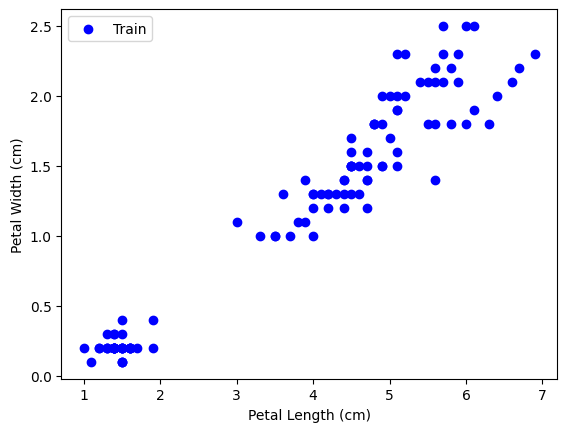

In [54]:
plt.scatter(train_x.PetalLengthCm, train_x.PetalWidthCm, c='blue', label='Train')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

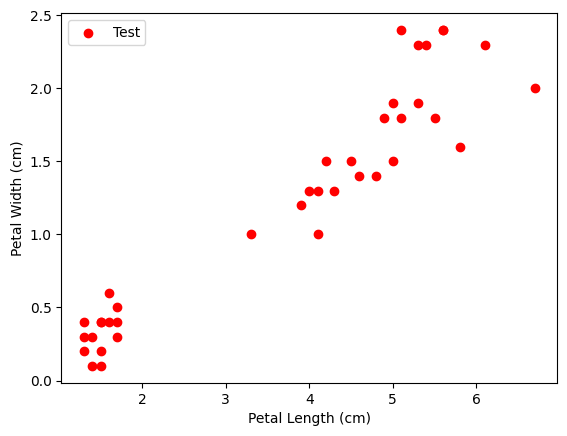

In [50]:
plt.scatter(test_x.PetalLengthCm, test_x.PetalWidthCm, c='red', label='Test')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

In [22]:
# SVM
model = svm.SVC()

In [23]:
model.fit(train_x, train_y)
pred = model.predict(test_x)

In [24]:
pred

array(['setosa', 'versicolor', 'virginica', 'virginica', 'virginica',
       'setosa', 'virginica', 'setosa', 'versicolor', 'versicolor',
       'virginica', 'versicolor', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'virginica', 'virginica', 'versicolor',
       'setosa', 'virginica', 'versicolor', 'setosa', 'setosa', 'setosa',
       'versicolor', 'setosa', 'virginica', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'setosa', 'setosa', 'setosa',
       'versicolor', 'versicolor'], dtype=object)

In [27]:
metrics.accuracy_score(pred, test_y)

0.9473684210526315

In [28]:
#Decision Tree
model = DecisionTreeClassifier()

In [29]:
model.fit(train_x, train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [30]:
pred_tree = model.predict(test_x)

In [32]:
metrics.accuracy_score(pred_tree, test_y)

0.9473684210526315

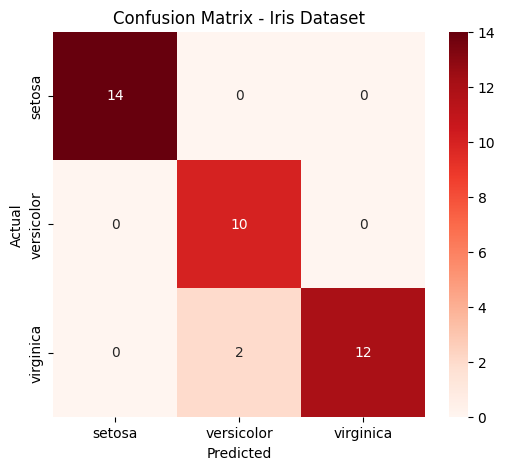

In [41]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

y = train["Species"]
le = LabelEncoder()
y = le.fit_transform(y)

cm = confusion_matrix(test_y, pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Dataset")
plt.show()

In [45]:
# -----------------------------
# Misclassification Analysis
# -----------------------------
print("\nMisclassified Samples:\n")

for actual, predicted in zip(test_y.to_numpy(), pred):
    if actual != predicted:
        print(f"Actual: {actual}, Predicted: {predicted}")


Misclassified Samples:

Actual: virginica, Predicted: versicolor
Actual: virginica, Predicted: versicolor
